# BTC Daily Correlation — Rubber Band v2
### Assets: BTCUSDT · DXY · USDT.D (Tether Dominance)
**New in this version:**
- Daily bars (not weekly)
- USDT Dominance as third asset (inverse of BTC by construction)
- Candle-direction correlation table: does BTC red → USDT.D green hold daily?
- Divergence detection: dates where expected correlation breaks
- Mirrored normalised price plot (BTC on +y, inverse assets on −y)

**Run cells top to bottom. All constants in Cell 2 only.**

## Cell 1 — Installs & Imports

In [1]:
# ── Cell 1: Installs & Imports ─────────────────────────────────────────────
import subprocess, sys
for pkg in ['yfinance', 'statsmodels', 'hmmlearn', 'scikit-learn', 'scipy', 'seaborn', 'pykalman']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr

from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from pykalman import KalmanFilter

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 25)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 120)
plt.style.use('dark_background')
np.random.seed(42)

print('✅ All imports complete.')

✅ All imports complete.


## Cell 2 — Master Config
**All constants, tickers, thresholds live here. Change nothing elsewhere.**

In [2]:
# ── Cell 2: Master Config ──────────────────────────────────────────────────

CFG = {
    # ── Tickers ───────────────────────────────────────────────────────────
    'TICKER_BTC'    : 'BTC-USD',       # Bitcoin/USD (yfinance)
    'TICKER_DXY'    : 'DX-Y.NYB',      # US Dollar Index
    # USDT.D = Tether dominance (% of total crypto market cap that is USDT)
    # Not on yfinance — we use 'BTC-USD' dominance proxy: TetherUSD/total cap
    # Best available proxy on yfinance: USDT-USD (Tether peg, nearly constant)
    # Better approach: use CRYPTOCAP:USDT.D from TradingView export
    # For programmatic access: use CoinGecko dominance or calculate from
    # total stablecoin mcap / total crypto mcap
    # ── USDT.D yfinance approach: we derive it from available data ────────
    # Total crypto mcap proxy = BTC mcap / BTC dominance
    # USDT dominance ≈ inverse of BTC dominance in many regimes
    # We use 'BTC.D' proxy: BTC mcap / (BTC mcap + ETH mcap + others)
    # Closest available yfinance tickers:
    'TICKER_USDT_D_PRIMARY'   : 'USDT-USD',    # Tether price (≈1, not useful alone)
    # We will derive USDT.D as: stablecoin_proxy / btc_price_normalized
    # The actual USDT.D data source options are noted in Cell 3

    # ── Data Parameters ───────────────────────────────────────────────────
    'INTERVAL'      : '1d',            # DAILY bars
    'START_DATE'    : '2020-01-01',    # 2020+ covers covid crash + bull + bear
    'END_DATE'      : '2025-01-01',

    # ── Rolling Windows (in daily bars) ───────────────────────────────────
    'CORR_WINDOW'   : 90,              # 90 days rolling correlation
    'SPREAD_WINDOW' : 365,             # 1 year for z-score baseline
    'HALFLIFE_CAP'  : 180,             # ignore if half-life > 6 months

    # ── Rubber Band Threshold ─────────────────────────────────────────────
    'ZSCORE_THRESH' : 2.0,             # ±2σ = extreme stretch

    # ── Candle Correlation Parameters ─────────────────────────────────────
    # Min absolute % move to count as a "meaningful" candle (filter noise)
    'MIN_CANDLE_PCT' : 0.0,            # 0 = every candle counts (even doji)
    # Forward look after divergence: how many days to measure BTC move
    'DIV_FWD_DAYS'  : [1, 3, 5, 10],
    # Minimum divergence streak to flag as notable
    'DIV_STREAK_MIN': 2,

    # ── HMM ───────────────────────────────────────────────────────────────
    'HMM_STATES'    : 3,
    'HMM_ITER'      : 200,

    # ── Visualization ─────────────────────────────────────────────────────
    'BG'     : '#0d0d0d',
    'TEAL'   : '#00e5cc',
    'ORANGE' : '#ff6b35',
    'RED'    : '#ff2d55',
    'BLUE'   : '#4da6ff',
    'YELLOW' : '#ffd700',
    'GREEN'  : '#39ff14',
    'GREY'   : '#3a3a3a',
    'WHITE'  : '#e8e8e8',

    'SAVE_FIGS'  : True,
    'FIG_PREFIX' : 'btc_daily_',
}

# Assets that are INVERSELY correlated with BTC (direction = -1)
# Assets that move WITH BTC (direction = +1)
ASSET_META = {
    'DXY'    : {'label': 'US Dollar Index (DXY)',     'direction': -1, 'color': CFG['RED']},
    'USDT_D' : {'label': 'USDT Dominance (USDT.D)',   'direction': -1, 'color': CFG['ORANGE']},
}
# Both are expected to be INVERSE to BTC:
# BTC up → DXY down, USDT.D down (capital flows OUT of stablecoins INTO BTC)
# BTC down → DXY up, USDT.D up (capital flows INTO stablecoins, risk-off)

print('✅ Config loaded.')
print(f'   Interval  : {CFG["INTERVAL"]} (DAILY)')
print(f'   Period    : {CFG["START_DATE"]} → {CFG["END_DATE"]}')
print(f'   Z-thresh  : ±{CFG["ZSCORE_THRESH"]}σ')
print(f'   Corr win  : {CFG["CORR_WINDOW"]} days')
print(f'   Assets    : BTC vs {list(ASSET_META.keys())}')

✅ Config loaded.
   Interval  : 1d (DAILY)
   Period    : 2020-01-01 → 2025-01-01
   Z-thresh  : ±2.0σ
   Corr win  : 90 days
   Assets    : BTC vs ['DXY', 'USDT_D']


## Cell 3 — Data Loader
**USDT.D note:** Tether Dominance is not on yfinance directly. We use two approaches:
1. **Primary:** `USDT-USD` (Tether price on yfinance) + derive dominance proxy
2. **Better:** Load from a CSV if you have exported CRYPTOCAP:USDT.D from TradingView
   - In TradingView: open CRYPTOCAP:USDT.D → Export data → place CSV path in `CFG['USDT_D_CSV']`

If no CSV is found, we build a **synthetic USDT.D proxy** = stablecoin market cap / total crypto cap approximation using available yfinance data.

In [3]:
# ── Cell 3: Data Loader ────────────────────────────────────────────────────
import os

# ── Robust single-ticker downloader ────────────────────────────────────────
def download_ohlcv(name, fallbacks, start, end, interval):
    """Download OHLCV — returns DataFrame with Open/High/Low/Close/Volume columns."""
    for ticker in fallbacks:
        try:
            df = yf.download(ticker, start=start, end=end,
                             interval=interval, progress=False, auto_adjust=True)
            if df is None or df.empty:
                continue
            # Flatten MultiIndex if present
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            required = [c for c in ['Open','High','Low','Close'] if c in df.columns]
            if not required:
                continue
            df = df[required].dropna()
            if len(df) < 30:
                continue
            df.index = pd.to_datetime(df.index)
            print(f'  [{name:<8}] ✅ {ticker:<16} {len(df):,} bars | '
                  f'{df.index[0].date()} → {df.index[-1].date()}')
            return df
        except Exception as e:
            print(f'    [{ticker}] failed: {e}')
    print(f'  [{name}] ❌ ALL fallbacks failed')
    return None

print('Downloading data...')

# ── BTC ───────────────────────────────────────────────────────────────────
btc_ohlcv = download_ohlcv('BTC', ['BTC-USD'],
                            CFG['START_DATE'], CFG['END_DATE'], CFG['INTERVAL'])

# ── DXY ───────────────────────────────────────────────────────────────────
dxy_ohlcv = download_ohlcv('DXY', ['DX-Y.NYB', 'DX=F'],
                            CFG['START_DATE'], CFG['END_DATE'], CFG['INTERVAL'])

# ── USDT Dominance ────────────────────────────────────────────────────────
# Strategy: try to load from CSV first, then build synthetic proxy
USDT_D_CSV = CFG.get('USDT_D_CSV', '')   # set path in CFG if you have it

usdt_d_ohlcv = None
usdt_d_source = ''

if USDT_D_CSV and os.path.exists(USDT_D_CSV):
    # ── Load from TradingView CSV export ──────────────────────────────────
    print('  Loading USDT.D from CSV...')
    try:
        csv_df = pd.read_csv(USDT_D_CSV, parse_dates=['time'])
        csv_df = csv_df.rename(columns={'time':'Date','open':'Open','high':'High',
                                         'low':'Low','close':'Close'})
        csv_df = csv_df.set_index('Date').sort_index()
        csv_df = csv_df[['Open','High','Low','Close']]
        mask = (csv_df.index >= CFG['START_DATE']) & (csv_df.index <= CFG['END_DATE'])
        usdt_d_ohlcv = csv_df[mask].dropna()
        usdt_d_source = 'TradingView CSV (CRYPTOCAP:USDT.D)'
        print(f'  [USDT_D  ] ✅ CSV  {len(usdt_d_ohlcv):,} bars | '
              f'{usdt_d_ohlcv.index[0].date()} → {usdt_d_ohlcv.index[-1].date()}')
    except Exception as e:
        print(f'  CSV load failed: {e}')

if usdt_d_ohlcv is None:
    # ── Synthetic USDT.D proxy ────────────────────────────────────────────
    # USDT.D = USDT market cap / Total crypto market cap
    # Proxy: total_stable / (total_stable + btc_mcap + eth_mcap)
    # We use: USDT-USD mcap not available directly on yfinance.
    # Best approach: use BTC dominance inverse.
    # BTC.D is not on yfinance either. We build:
    # synthetic_usdt_d = 1 / (BTC_price / BTC_price.rolling(365).mean())
    # which captures the relative strength of stablecoins vs BTC.
    # This is an APPROXIMATION. For real USDT.D, use TradingView CSV.
    print('  Building synthetic USDT.D proxy from BTC price...')
    print('  ⚠️  This is a proxy. For real USDT.D: export CRYPTOCAP:USDT.D from TradingView.')

    # Download ETH as an additional component for the proxy
    eth_df = download_ohlcv('ETH', ['ETH-USD'],
                             CFG['START_DATE'], CFG['END_DATE'], CFG['INTERVAL'])

    if btc_ohlcv is not None and eth_df is not None:
        # Normalise both to their starting price
        btc_norm = btc_ohlcv['Close'] / btc_ohlcv['Close'].iloc[0]
        eth_norm = eth_df['Close']   / eth_df['Close'].iloc[0]

        # Risk asset index = weighted avg of BTC + ETH normalized prices
        risk_idx = (btc_norm * 0.65 + eth_norm * 0.35)

        # USDT.D proxy = inverse of risk appetite (when risk assets go up, USDT.D falls)
        # Scale to realistic USDT.D range (roughly 4% to 12%)
        raw_proxy = 1 / risk_idx
        # Scale to [4, 12] range to mimic real USDT.D
        pmin, pmax = raw_proxy.min(), raw_proxy.max()
        usdt_d_close = 4 + (raw_proxy - pmin) / (pmax - pmin) * 8

        # Build OHLCV-like dataframe (O=H=L=C for synthetic, no intraday data)
        usdt_d_ohlcv = pd.DataFrame({
            'Open'  : usdt_d_close,
            'High'  : usdt_d_close * 1.001,
            'Low'   : usdt_d_close * 0.999,
            'Close' : usdt_d_close,
        }).dropna()
        usdt_d_source = 'Synthetic proxy (1/BTC+ETH norm, scaled 4-12%)'
        print(f'  [USDT_D  ] ✅ Synthetic  {len(usdt_d_ohlcv):,} bars')
    else:
        print('  [USDT_D  ] ❌ Cannot build proxy without BTC/ETH data')

print(f'\n  USDT.D source: {usdt_d_source}')

# ── Align all assets to common daily index ─────────────────────────────────
print('\nAligning to common date index...')

ohlcv_map = {}
if btc_ohlcv is not None:    ohlcv_map['BTC']    = btc_ohlcv
if dxy_ohlcv is not None:    ohlcv_map['DXY']    = dxy_ohlcv
if usdt_d_ohlcv is not None: ohlcv_map['USDT_D'] = usdt_d_ohlcv

# Common close prices
close_raw = pd.DataFrame({k: v['Close'] for k, v in ohlcv_map.items()})
close_raw.index = pd.to_datetime(close_raw.index)
close_raw = close_raw.dropna()

# Common open prices (needed for candle direction analysis)
open_raw = pd.DataFrame({k: v['Open'] for k, v in ohlcv_map.items()})
open_raw.index = pd.to_datetime(open_raw.index)
open_raw = open_raw.reindex(close_raw.index).dropna()
close_raw = close_raw.reindex(open_raw.index)

price_df = close_raw.copy()
open_df  = open_raw.copy()

print(f'\nAligned dataset: {len(price_df):,} daily bars')
print(f'  From: {price_df.index[0].date()} → {price_df.index[-1].date()}')
print(f'  Columns: {list(price_df.columns)}')

ACTIVE_ASSETS = [a for a in ['DXY', 'USDT_D'] if a in price_df.columns]
print(f'  Active assets: {ACTIVE_ASSETS}')

# ── Derived series ─────────────────────────────────────────────────────────
ret_df   = np.log(price_df / price_df.shift(1)).dropna()
norm_df  = (price_df / price_df.iloc[0]) * 100

# Candle direction: +1 = green (close > open), -1 = red (close < open)
candle_dir = pd.DataFrame(index=price_df.index)
for col in price_df.columns:
    candle_dir[col] = np.sign(price_df[col] - open_df[col])

# % candle body size
candle_pct = pd.DataFrame(index=price_df.index)
for col in price_df.columns:
    candle_pct[col] = (price_df[col] - open_df[col]) / open_df[col] * 100

print('\nPrice summary:')
print(price_df.describe().round(4))

  [BTC     ] ✅ BTC-USD          1,827 bars | 2020-01-01 → 2024-12-31
  [DXY     ] ✅ DX-Y.NYB         1,258 bars | 2020-01-02 → 2024-12-31
  Building synthetic USDT.D proxy from BTC price...
  ⚠️  This is a proxy. For real USDT.D: export CRYPTOCAP:USDT.D from TradingView.
  [ETH     ] ✅ ETH-USD          1,827 bars | 2020-01-01 → 2024-12-31
  [USDT_D  ] ✅ Synthetic  1,827 bars

  USDT.D source: Synthetic proxy (1/BTC+ETH norm, scaled 4-12%)

Aligning to common date index...

Aligned dataset: 1,258 daily bars
  From: 2020-01-02 → 2024-12-31
  Columns: ['BTC', 'DXY', 'USDT_D']
  Active assets: ['DXY', 'USDT_D']

Price summary:
              BTC       DXY    USDT_D
count   1258.0000 1258.0000 1258.0000
mean   36334.0706   99.9909    5.0356
std    21095.9080    5.7696    1.4503
min     4970.7881   89.4400    4.0000
25%    19644.6797   94.1450    4.1970
50%    32211.8994  101.5300    4.4821
75%    50771.3916  104.3200    4.8954
max   106140.6016  114.1100   12.0000


## Cell 4 — Utility Functions
Same core math as v1 — ADF, half-life, spread z-score, Kalman, Engle-Granger, rolling correlation.

In [4]:
# ── Cell 4: Utility Functions ──────────────────────────────────────────────

def adf_test(series, label=''):
    result = adfuller(series.dropna(), autolag='AIC')
    return {'label': label, 'adf_stat': result[0], 'p_value': result[1],
            'stationary': result[1] < 0.05,
            'crit_1pct': result[4]['1%'], 'crit_5pct': result[4]['5%']}

def compute_half_life(spread):
    spread = spread.dropna()
    delta  = spread.diff().dropna()
    lag    = spread.shift(1).dropna()
    delta, lag = delta.align(lag, join='inner')
    model  = OLS(delta, add_constant(lag)).fit()
    phi    = model.params.iloc[1]
    if phi >= 0 or phi <= -2:
        return np.nan
    return -np.log(2) / np.log(1 + phi)

def compute_spread_zscore(btc_log, macro_log, beta, window):
    spread    = btc_log - beta * macro_log
    roll_mean = spread.rolling(window).mean()
    roll_std  = spread.rolling(window).std()
    z = (spread - roll_mean) / (roll_std + 1e-10)
    return spread, z

def kalman_hedge_ratio(btc_log, macro_log):
    obs    = btc_log.values
    states = macro_log.values
    n      = len(obs)
    obs_mat = np.vstack([states, np.ones(n)]).T[:, np.newaxis, :]
    kf = KalmanFilter(
        n_dim_obs=1, n_dim_state=2,
        initial_state_mean=[0, 0],
        initial_state_covariance=np.eye(2),
        transition_matrices=np.eye(2),
        observation_matrices=obs_mat,
        observation_covariance=1.0,
        transition_covariance=1e-3 * np.eye(2),
    )
    state_means, _ = kf.filter(obs)
    return (pd.Series(state_means[:, 0], index=btc_log.index, name='kalman_beta'),
            pd.Series(state_means[:, 1], index=btc_log.index, name='kalman_alpha'))

def engle_granger_coint(btc_log, macro_log, label=''):
    score, pval, crits = coint(btc_log, macro_log)
    return {'label': label, 'coint_stat': score, 'p_value': pval,
            'cointegrated': pval < 0.05, 'crit_5pct': crits[1]}

def rolling_correlation(ret_a, ret_b, window):
    corr, idx = [], ret_a.index[window:]
    for i in range(window, len(ret_a)):
        r, _ = spearmanr(ret_a.iloc[i-window:i].values,
                          ret_b.iloc[i-window:i].values)
        corr.append(r)
    return pd.Series(corr, index=idx, name='roll_corr')

print('✅ Utility functions defined.')

✅ Utility functions defined.


## Cell 5 — BTC vs DXY Analysis
Full cointegration, Kalman, spread z-score, half-life, rolling correlation on daily data.

In [5]:
# ── Cell 5: BTC vs DXY (Daily) ────────────────────────────────────────────

ASSET = 'DXY'
RESULTS = {}

if ASSET not in price_df.columns:
    print(f'⚠️  {ASSET} not loaded — skipping.')
else:
    print(f'=== BTC vs {ASSET_META[ASSET]["label"]} (Daily) ===')

    btc_log = np.log(price_df['BTC'])
    dxy_log = np.log(price_df[ASSET])
    btc_ret = ret_df['BTC']
    dxy_ret = ret_df[ASSET]

    aligned = pd.concat([btc_ret, dxy_ret], axis=1).dropna()
    pr, pp  = pearsonr(aligned.iloc[:,0], aligned.iloc[:,1])
    sr, sp  = spearmanr(aligned.iloc[:,0], aligned.iloc[:,1])
    print(f'\nStatic correlation (full period, daily):')
    print(f'  Pearson  r = {pr:.4f}  p = {pp:.6f}  → {"significant" if pp<0.05 else "NOT significant"}')
    print(f'  Spearman r = {sr:.4f}  p = {sp:.6f}  → {"significant" if sp<0.05 else "NOT significant"}')

    coint_res = engle_granger_coint(btc_log, dxy_log, label='BTC/DXY')
    print(f'\nEngle-Granger cointegration:')
    print(f'  stat={coint_res["coint_stat"]:.4f}  p={coint_res["p_value"]:.4f}')
    print(f'  Result: {"✅ COINTEGRATED" if coint_res["cointegrated"] else "❌ NOT cointegrated"}')

    beta_dxy, alpha_dxy = kalman_hedge_ratio(btc_log, dxy_log)
    print(f'\nKalman β: mean={beta_dxy.mean():.4f} | range=[{beta_dxy.min():.3f}, {beta_dxy.max():.3f}]')

    spread_dxy, zscore_dxy = compute_spread_zscore(
        btc_log, dxy_log, beta_dxy.mean(), CFG['SPREAD_WINDOW'])

    adf_res = adf_test(spread_dxy, 'BTC/DXY spread')
    print(f'\nADF on spread: stat={adf_res["adf_stat"]:.4f}  p={adf_res["p_value"]:.4f}')
    print(f'  {"✅ Stationary" if adf_res["stationary"] else "❌ Not stationary"}')

    hl_dxy = compute_half_life(spread_dxy)
    print(f'\nHalf-life: {hl_dxy:.1f} days (~{hl_dxy/30:.1f} months)')

    roll_corr_dxy  = rolling_correlation(btc_ret, dxy_ret, CFG['CORR_WINDOW'])
    extreme_dxy    = zscore_dxy[zscore_dxy.abs() > CFG['ZSCORE_THRESH']].dropna()

    print(f'\nRubber band extremes (|z| > {CFG["ZSCORE_THRESH"]}):')
    print(f'  Total: {len(extreme_dxy)} days')
    print(f'  +z (BTC stretched above DXY): {(extreme_dxy > CFG["ZSCORE_THRESH"]).sum()}')
    print(f'  -z (BTC stretched below DXY): {(extreme_dxy < -CFG["ZSCORE_THRESH"]).sum()}')

    RESULTS['DXY'] = {
        'pearson_r': pr, 'spearman_r': sr,
        'cointegrated': coint_res['cointegrated'], 'coint_p': coint_res['p_value'],
        'spread': spread_dxy, 'zscore': zscore_dxy,
        'roll_corr': roll_corr_dxy, 'half_life': hl_dxy,
        'beta': beta_dxy, 'adf_p': adf_res['p_value'],
        'spread_stationary': adf_res['stationary'],
        'extreme_events': extreme_dxy,
    }
    print('\n✅ DXY analysis complete.')

=== BTC vs US Dollar Index (DXY) (Daily) ===

Static correlation (full period, daily):
  Pearson  r = -0.1479  p = 0.000000  → significant
  Spearman r = -0.1811  p = 0.000000  → significant

Engle-Granger cointegration:
  stat=-1.4214  p=0.7901
  Result: ❌ NOT cointegrated

Kalman β: mean=2.1224 | range=[1.767, 2.334]

ADF on spread: stat=-1.5152  p=0.5260
  ❌ Not stationary

Half-life: 232.1 days (~7.7 months)

Rubber band extremes (|z| > 2.0):
  Total: 163 days
  +z (BTC stretched above DXY): 68
  -z (BTC stretched below DXY): 95

✅ DXY analysis complete.


## Cell 6 — BTC vs USDT.D Analysis
USDT.D is the most direct inverse signal: when traders are fearful they move INTO Tether (USDT.D rises) and OUT of BTC. This is crypto-native risk-off.

In [6]:
# ── Cell 6: BTC vs USDT.D (Daily) ─────────────────────────────────────────

ASSET = 'USDT_D'

if ASSET not in price_df.columns:
    print(f'⚠️  {ASSET} not loaded — skipping.')
else:
    print(f'=== BTC vs {ASSET_META[ASSET]["label"]} (Daily) ===')

    btc_log    = np.log(price_df['BTC'])
    usdt_d_log = np.log(price_df[ASSET])
    btc_ret    = ret_df['BTC']
    usdt_d_ret = ret_df[ASSET]

    aligned = pd.concat([btc_ret, usdt_d_ret], axis=1).dropna()
    pr, pp  = pearsonr(aligned.iloc[:,0], aligned.iloc[:,1])
    sr, sp  = spearmanr(aligned.iloc[:,0], aligned.iloc[:,1])
    print(f'\nStatic correlation:')
    print(f'  Pearson  r = {pr:.4f}  p = {pp:.6f}')
    print(f'  Spearman r = {sr:.4f}  p = {sp:.6f}')
    exp_sign = ASSET_META[ASSET]['direction']
    print(f'  Expected direction: {exp_sign} | Actual sign: {int(np.sign(sr))}')
    print(f'  Direction check: {"✅ Correct" if np.sign(sr)==exp_sign else "⚠️ Unexpected direction"}')

    coint_res = engle_granger_coint(btc_log, usdt_d_log, label='BTC/USDT.D')
    print(f'\nEngle-Granger cointegration:')
    print(f'  stat={coint_res["coint_stat"]:.4f}  p={coint_res["p_value"]:.4f}')
    print(f'  Result: {"✅ COINTEGRATED" if coint_res["cointegrated"] else "❌ NOT cointegrated"}')

    beta_ud, alpha_ud = kalman_hedge_ratio(btc_log, usdt_d_log)
    print(f'\nKalman β: mean={beta_ud.mean():.4f} | range=[{beta_ud.min():.3f}, {beta_ud.max():.3f}]')

    spread_ud, zscore_ud = compute_spread_zscore(
        btc_log, usdt_d_log, beta_ud.mean(), CFG['SPREAD_WINDOW'])

    adf_res = adf_test(spread_ud, 'BTC/USDT.D spread')
    print(f'\nADF on spread: stat={adf_res["adf_stat"]:.4f}  p={adf_res["p_value"]:.4f}')
    print(f'  {"✅ Stationary" if adf_res["stationary"] else "❌ Not stationary"}')

    hl_ud = compute_half_life(spread_ud)
    print(f'\nHalf-life: {hl_ud:.1f} days (~{hl_ud/30:.1f} months)')

    roll_corr_ud = rolling_correlation(btc_ret, usdt_d_ret, CFG['CORR_WINDOW'])
    extreme_ud   = zscore_ud[zscore_ud.abs() > CFG['ZSCORE_THRESH']].dropna()

    print(f'\nRubber band extremes: {len(extreme_ud)} days')
    print(f'  +z (BTC too high vs USDT.D): {(extreme_ud > CFG["ZSCORE_THRESH"]).sum()}')
    print(f'  -z (BTC too low vs USDT.D) : {(extreme_ud < -CFG["ZSCORE_THRESH"]).sum()}')

    RESULTS['USDT_D'] = {
        'pearson_r': pr, 'spearman_r': sr,
        'cointegrated': coint_res['cointegrated'], 'coint_p': coint_res['p_value'],
        'spread': spread_ud, 'zscore': zscore_ud,
        'roll_corr': roll_corr_ud, 'half_life': hl_ud,
        'beta': beta_ud, 'adf_p': adf_res['p_value'],
        'spread_stationary': adf_res['stationary'],
        'extreme_events': extreme_ud,
    }
    print('\n✅ USDT.D analysis complete.')

=== BTC vs USDT Dominance (USDT.D) (Daily) ===

Static correlation:
  Pearson  r = -0.7767  p = 0.000000
  Spearman r = -0.8810  p = 0.000000
  Expected direction: -1 | Actual sign: -1
  Direction check: ✅ Correct

Engle-Granger cointegration:
  stat=-1.1130  p=0.8792
  Result: ❌ NOT cointegrated

Kalman β: mean=2.6714 | range=[2.002, 3.464]

ADF on spread: stat=-1.8282  p=0.3665
  ❌ Not stationary

Half-life: 172.0 days (~5.7 months)

Rubber band extremes: 120 days
  +z (BTC too high vs USDT.D): 76
  -z (BTC too low vs USDT.D) : 44

✅ USDT.D analysis complete.


## Cell 7 — HMM Regime Detection
3-state Hidden Markov Model on daily spread z-score + rolling correlation. Identifies when the rubber band is active vs broken.

In [7]:
# ── Cell 7: HMM Regime Detection (Daily) ──────────────────────────────────

print('=== HMM Regime Detection (Daily) ===')
HMM_RESULTS = {}

for asset in ACTIVE_ASSETS:
    print(f'\n[{asset}]')
    if asset not in RESULTS:
        print('  No RESULTS entry — skipping.')
        continue
    try:
        z      = RESULTS[asset]['zscore'].dropna()
        rc     = RESULTS[asset]['roll_corr'].reindex(z.index).dropna()
        br     = ret_df['BTC'].reindex(z.index).dropna()
        mr     = ret_df[asset].reindex(z.index).dropna()

        common = z.index.intersection(rc.index).intersection(br.index).intersection(mr.index)
        feats  = pd.DataFrame({
            'zscore'    : z.reindex(common),
            'roll_corr' : rc.reindex(common),
            'btc_ret'   : br.reindex(common),
            'macro_ret' : mr.reindex(common),
        }).dropna()

        if len(feats) < CFG['HMM_STATES'] * 20:
            print(f'  Not enough data ({len(feats)} rows)')
            continue

        scaler = StandardScaler()
        X      = scaler.fit_transform(feats.values)

        model  = GaussianHMM(n_components=CFG['HMM_STATES'],
                              covariance_type='full',
                              n_iter=CFG['HMM_ITER'], random_state=42)
        model.fit(X)
        states = model.predict(X)

        feats['regime'] = states
        summary = feats.groupby('regime')[['zscore','roll_corr','btc_ret']].mean()
        summary['count'] = feats.groupby('regime').size()
        summary['pct']   = summary['count'] / len(feats) * 100
        print(summary.round(4).to_string())

        HMM_RESULTS[asset] = {
            'model'      : model,
            'states'     : pd.Series(states, index=feats.index, name='regime'),
            'features'   : feats,
            'state_stats': summary,
            'scaler'     : scaler,
        }
    except Exception as e:
        print(f'  HMM failed: {e}')

print('\n✅ HMM complete.')

=== HMM Regime Detection (Daily) ===

[DXY]
        zscore  roll_corr  btc_ret  count     pct
regime                                           
0      -2.1324    -0.2768  -0.0041    154 17.2260
1       0.4788    -0.3887   0.0014    169 18.9038
2       0.9169    -0.1148   0.0023    571 63.8702

[USDT_D]
        zscore  roll_corr  btc_ret  count     pct
regime                                           
0      -1.8683    -0.9299  -0.0005    180 20.1342
1       0.1260    -0.9339  -0.0009    226 25.2796
2       1.3599    -0.8955   0.0025    488 54.5861

✅ HMM complete.


## Cell 8 — Stretch Range & Forward Return Analysis
Measures empirical rubber band limits on daily data. Forward BTC returns after extreme z-score events.

In [8]:
# ── Cell 8: Stretch Range & Forward Return Analysis ────────────────────────

print('=== Rubber Band Stretch Range (Daily) ===')
STRETCH = {}

for asset in ACTIVE_ASSETS:
    if asset not in RESULTS:
        continue
    print(f'\n[{asset}]')
    z         = RESULTS[asset]['zscore'].dropna()
    btc_close = price_df['BTC'].reindex(z.index)

    pcts     = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    pct_vals = np.percentile(z.dropna(), pcts)
    print(f'  Z-score percentiles: {dict(zip(pcts, pct_vals.round(3)))}')
    print(f'  Max stretch: {z.abs().max():.2f}σ')
    print(f'  % time |z|>2σ: {(z.abs()>2).mean()*100:.1f}%')
    print(f'  % time |z|>3σ: {(z.abs()>3).mean()*100:.1f}%')

    fwd_records = []
    for thresh in [1.5, 2.0, 2.5, 3.0]:
        for direction, label in [(z > thresh, f'+{thresh}σ'), (z < -thresh, f'-{thresh}σ')]:
            for ts in z[direction].index:
                loc = z.index.get_loc(ts)
                for fwd in [1, 3, 5, 10, 21, 63]:
                    if loc + fwd < len(btc_close):
                        ret = (btc_close.iloc[loc+fwd] / btc_close.iloc[loc] - 1) * 100
                        fwd_records.append({
                            'threshold': label, 'fwd_days': fwd,
                            'btc_ret': ret, 'z_val': z.iloc[loc]
                        })

    fwd_df = pd.DataFrame(fwd_records)
    if len(fwd_df) > 0:
        summary = fwd_df.groupby(['threshold','fwd_days'])['btc_ret'].agg(
            mean='mean', std='std', count='count',
            win_pct=lambda x: (x > 0).mean() * 100
        ).round(3)
        print(f'\n  Forward BTC return after z-extreme:')
        print(summary.to_string())

    runs, count = [], 0
    for val in (z.abs() > CFG['ZSCORE_THRESH']):
        if val: count += 1
        elif count > 0: runs.append(count); count = 0
    if runs:
        print(f'\n  Duration at extreme: mean={np.mean(runs):.1f}d | max={max(runs)}d | median={np.median(runs):.1f}d')

    STRETCH[asset] = {
        'pct_vals': dict(zip(pcts, pct_vals)), 'max_z': z.abs().max(),
        'pct_2sd': (z.abs()>2).mean()*100, 'pct_3sd': (z.abs()>3).mean()*100,
        'fwd_df': fwd_df, 'run_lengths': runs,
    }

print('\n✅ Stretch analysis complete.')

=== Rubber Band Stretch Range (Daily) ===

[DXY]
  Z-score percentiles: {1: np.float64(-3.23), 5: np.float64(-2.241), 10: np.float64(-2.032), 25: np.float64(-0.513), 50: np.float64(0.587), 75: np.float64(1.31), 90: np.float64(1.824), 95: np.float64(2.151), 99: np.float64(2.503)}
  Max stretch: 3.56σ
  % time |z|>2σ: 18.2%
  % time |z|>3σ: 2.0%

  Forward BTC return after z-extreme:
                       mean     std  count  win_pct
threshold fwd_days                                 
+1.5σ     1          0.3690  3.3970    182  52.7470
          3          1.1290  5.4030    182  54.9450
          5          1.9260  7.1900    181  60.2210
          10         3.7040  9.8790    178  60.6740
          21         7.8730 17.1310    167  62.2750
          63        20.2520 29.0970    153  64.0520
+2.0σ     1          0.5180  4.0470     68  52.9410
          3          0.8990  5.5640     68  52.9410
          5          1.5520  8.0530     68  57.3530
          10         2.3490 10.4500     68 

## Cell 9 — ⭐ Candle Direction Correlation Table
**New analysis.** For each trading day: was BTC red/green and was USDT.D/DXY the opposite?  
Measures: correlation hold rate, what happens when it breaks (divergence), and forward BTC returns after divergence.

In [9]:
# ── Cell 9: Candle Direction Correlation & Divergence Analysis ─────────────

print('=== CANDLE DIRECTION CORRELATION ANALYSIS ===')
print('Logic: Inverse assets should move OPPOSITE direction to BTC each day.')
print('       BTC green → DXY red  (and vice versa)')
print('       BTC green → USDT.D red (and vice versa)')
print('Divergence = both move in SAME direction (correlation breaks)\n')

CANDLE_RESULTS = {}
DIV_TABLES     = {}   # separate divergence table per asset

for asset in ACTIVE_ASSETS:
    if asset not in candle_dir.columns or 'BTC' not in candle_dir.columns:
        continue

    print(f'\n{"─"*60}')
    print(f'BTC vs {ASSET_META[asset]["label"]}')
    print(f'{"─"*60}')

    btc_d  = candle_dir['BTC']
    mac_d  = candle_dir[asset]
    btc_p  = candle_pct['BTC']
    mac_p  = candle_pct[asset]

    # Align
    df_c = pd.DataFrame({
        'btc_dir'  : btc_d,
        'mac_dir'  : mac_d,
        'btc_pct'  : btc_p,
        'mac_pct'  : mac_p,
        'btc_close': price_df['BTC'],
    }).dropna()

    # Exclude doji (close == open, direction = 0)
    df_c = df_c[(df_c['btc_dir'] != 0) & (df_c['mac_dir'] != 0)].copy()

    total = len(df_c)

    # ── Correlation holds: BTC and macro move OPPOSITE directions ─────────
    # For inverse assets: correlated = BTC_dir != MAC_dir
    df_c['corr_holds']   = df_c['btc_dir'] != df_c['mac_dir']   # True = expected
    df_c['divergence']   = df_c['btc_dir'] == df_c['mac_dir']   # True = break

    # Divergence sub-types
    df_c['div_both_green'] = (df_c['btc_dir'] == 1) & (df_c['mac_dir'] == 1)
    df_c['div_both_red']   = (df_c['btc_dir'] == -1) & (df_c['mac_dir'] == -1)

    n_corr = df_c['corr_holds'].sum()
    n_div  = df_c['divergence'].sum()

    print(f'\n  Total days analysed : {total}')
    print(f'  Correlation holds   : {n_corr} days ({n_corr/total*100:.1f}%)')
    print(f'  Divergence (break)  : {n_div}  days ({n_div/total*100:.1f}%)')
    print(f'    Both green        : {df_c["div_both_green"].sum()} days  (BTC↑ + {asset}↑ — risk-on surge ignored stablecoin flow)')
    print(f'    Both red          : {df_c["div_both_red"].sum()}  days  (BTC↓ + {asset}↓ — unusual, both selling)')

    # ── Contingency table ─────────────────────────────────────────────────
    print(f'\n  Contingency table (BTC dir × {asset} dir):')
    ct = pd.crosstab(df_c['btc_dir'].map({1:'BTC Green', -1:'BTC Red'}),
                     df_c['mac_dir'].map({1:f'{asset} Green', -1:f'{asset} Red'}),
                     margins=True)
    print(ct.to_string())

    # ── BTC forward return after divergence ───────────────────────────────
    print(f'\n  BTC forward return after DIVERGENCE (correlation break):')
    div_idx  = df_c[df_c['divergence']].index
    fwd_recs = []
    closes   = price_df['BTC']

    for ts in div_idx:
        loc = closes.index.get_loc(ts)
        row = df_c.loc[ts]
        div_type = 'BOTH_GREEN' if row['div_both_green'] else 'BOTH_RED'
        for fwd in CFG['DIV_FWD_DAYS']:
            if loc + fwd < len(closes):
                ret = (closes.iloc[loc+fwd] / closes.iloc[loc] - 1) * 100
                fwd_recs.append({
                    'date'    : ts.date(),
                    'div_type': div_type,
                    'fwd_days': fwd,
                    'btc_ret' : ret,
                    'btc_pct_day': row['btc_pct'],
                    'mac_pct_day': row['mac_pct'],
                })

    fwd_df = pd.DataFrame(fwd_recs)
    if len(fwd_df) > 0:
        summary_fwd = fwd_df.groupby(['div_type','fwd_days'])['btc_ret'].agg(
            mean='mean', std='std', count='count',
            win_pct=lambda x: (x > 0).mean() * 100
        ).round(3)
        print(summary_fwd.to_string())

    # ── Divergence streak analysis ─────────────────────────────────────────
    print(f'\n  Divergence streak analysis (consecutive divergence days):')
    streak_records = []
    streak, streak_start = 0, None
    for ts, row in df_c.iterrows():
        if row['divergence']:
            streak += 1
            if streak == 1:
                streak_start = ts
        else:
            if streak >= CFG['DIV_STREAK_MIN']:
                streak_records.append({'start': streak_start.date(), 'length': streak})
            streak = 0
    if streak_records:
        streak_df = pd.DataFrame(streak_records)
        print(f'  Streaks ≥{CFG["DIV_STREAK_MIN"]} days: {len(streak_df)}')
        print(f'  Longest streak: {streak_df["length"].max()} days')
        print(f'  Top 10 longest divergence streaks:')
        print(streak_df.nlargest(10, 'length').to_string(index=False))

    CANDLE_RESULTS[asset] = {
        'df'        : df_c,
        'n_total'   : total,
        'n_corr'    : n_corr,
        'n_div'     : n_div,
        'corr_rate' : n_corr / total,
        'fwd_df'    : fwd_df,
        'streaks'   : streak_records,
    }
    DIV_TABLES[asset] = df_c[df_c['divergence']].copy()

print('\n✅ Candle correlation analysis complete.')

=== CANDLE DIRECTION CORRELATION ANALYSIS ===
Logic: Inverse assets should move OPPOSITE direction to BTC each day.
       BTC green → DXY red  (and vice versa)
       BTC green → USDT.D red (and vice versa)
Divergence = both move in SAME direction (correlation breaks)


────────────────────────────────────────────────────────────
BTC vs US Dollar Index (DXY)
────────────────────────────────────────────────────────────

  Total days analysed : 1244
  Correlation holds   : 722 days (58.0%)
  Divergence (break)  : 522  days (42.0%)
    Both green        : 276 days  (BTC↑ + DXY↑ — risk-on surge ignored stablecoin flow)
    Both red          : 246  days  (BTC↓ + DXY↓ — unusual, both selling)

  Contingency table (BTC dir × DXY dir):
mac_dir    DXY Green  DXY Red   All
btc_dir                            
BTC Green        276      354   630
BTC Red          368      246   614
All              644      600  1244

  BTC forward return after DIVERGENCE (correlation break):
                     

## Cell 10 — ⭐ Divergence Dates Table
Complete table of every day where the inverse correlation broke — sorted by date, with BTC and asset candle size and type.

In [10]:
# ── Cell 10: Full Divergence Dates Table ──────────────────────────────────

print('=== FULL DIVERGENCE DATE TABLE ===')
print('These are ALL days where the inverse correlation broke.')
print('Both BTC and the macro asset moved in the SAME direction.\n')

for asset in ACTIVE_ASSETS:
    if asset not in DIV_TABLES:
        continue

    div_df = DIV_TABLES[asset].copy()
    div_df['Date']         = div_df.index.strftime('%Y-%m-%d')
    div_df['BTC_candle']   = div_df['btc_dir'].map({1: '🟢 GREEN', -1: '🔴 RED'})
    div_df[f'{asset}_candle'] = div_df['mac_dir'].map({1: '🟢 GREEN', -1: '🔴 RED'})
    div_df['BTC_%']        = div_df['btc_pct'].round(2).astype(str) + '%'
    div_df[f'{asset}_%']   = div_df['mac_pct'].round(2).astype(str) + '%'
    div_df['Type']         = div_df['div_both_green'].map({True: 'BOTH GREEN', False: 'BOTH RED'})

    display_cols = ['Date', 'BTC_candle', 'BTC_%',
                    f'{asset}_candle', f'{asset}_%', 'Type']

    out = div_df[display_cols].reset_index(drop=True)

    print(f'\n── BTC vs {ASSET_META[asset]["label"]} — {len(out)} divergence days ──')
    print(out.to_string(index=False))

    print(f'\n  Summary:')
    print(f'  Both GREEN (BTC↑ + {asset}↑): {div_df["div_both_green"].sum()} days')
    print(f'  Both RED   (BTC↓ + {asset}↓): {div_df["div_both_red"].sum()}  days')

    # Year breakdown
    div_df['Year'] = pd.to_datetime(div_df['Date']).dt.year
    yearly = div_df.groupby('Year').size().rename('divergence_days')
    total_per_year = candle_dir.resample('YE').count()['BTC']
    yearly_pct = (yearly / total_per_year * 100).round(1)
    print(f'\n  Divergence days per year:')
    for yr in sorted(yearly.index):
        print(f'    {yr}: {yearly.get(yr, 0)} days ({yearly_pct.get(str(yr)+"-12-31", yearly_pct.get(yr, "?"))}%)')

=== FULL DIVERGENCE DATE TABLE ===
These are ALL days where the inverse correlation broke.
Both BTC and the macro asset moved in the SAME direction.


── BTC vs US Dollar Index (DXY) — 522 divergence days ──
      Date BTC_candle   BTC_% DXY_candle  DXY_%       Type
2020-01-03    🟢 GREEN   5.16%    🟢 GREEN  0.05% BOTH GREEN
2020-01-07    🟢 GREEN   5.08%    🟢 GREEN  0.34% BOTH GREEN
2020-01-14    🟢 GREEN   8.44%    🟢 GREEN  0.01% BOTH GREEN
2020-01-15      🔴 RED  -0.21%      🔴 RED -0.15%   BOTH RED
2020-01-17    🟢 GREEN   2.34%    🟢 GREEN  0.31% BOTH GREEN
2020-01-22      🔴 RED  -0.72%      🔴 RED -0.09%   BOTH RED
2020-01-24    🟢 GREEN   0.47%    🟢 GREEN  0.13% BOTH GREEN
2020-01-27    🟢 GREEN   3.63%    🟢 GREEN  0.08% BOTH GREEN
2020-01-28    🟢 GREEN    5.0%    🟢 GREEN  0.07% BOTH GREEN
2020-01-31      🔴 RED  -1.66%      🔴 RED -0.49%   BOTH RED
2020-02-05    🟢 GREEN   4.68%    🟢 GREEN  0.34% BOTH GREEN
2020-02-06    🟢 GREEN   1.16%    🟢 GREEN  0.21% BOTH GREEN
2020-02-07    🟢 GREEN   0

## Cell 11 — ⭐ Mirrored Normalised Price Plot
BTC on positive Y-axis. Inverse assets FLIPPED onto negative Y-axis (mirrored).  
**If the rubber band is real:** the flipped inverse asset should TRACK BTC's shape closely.  
**Where they diverge:** that's where the correlation broke and a potential BTC move followed.

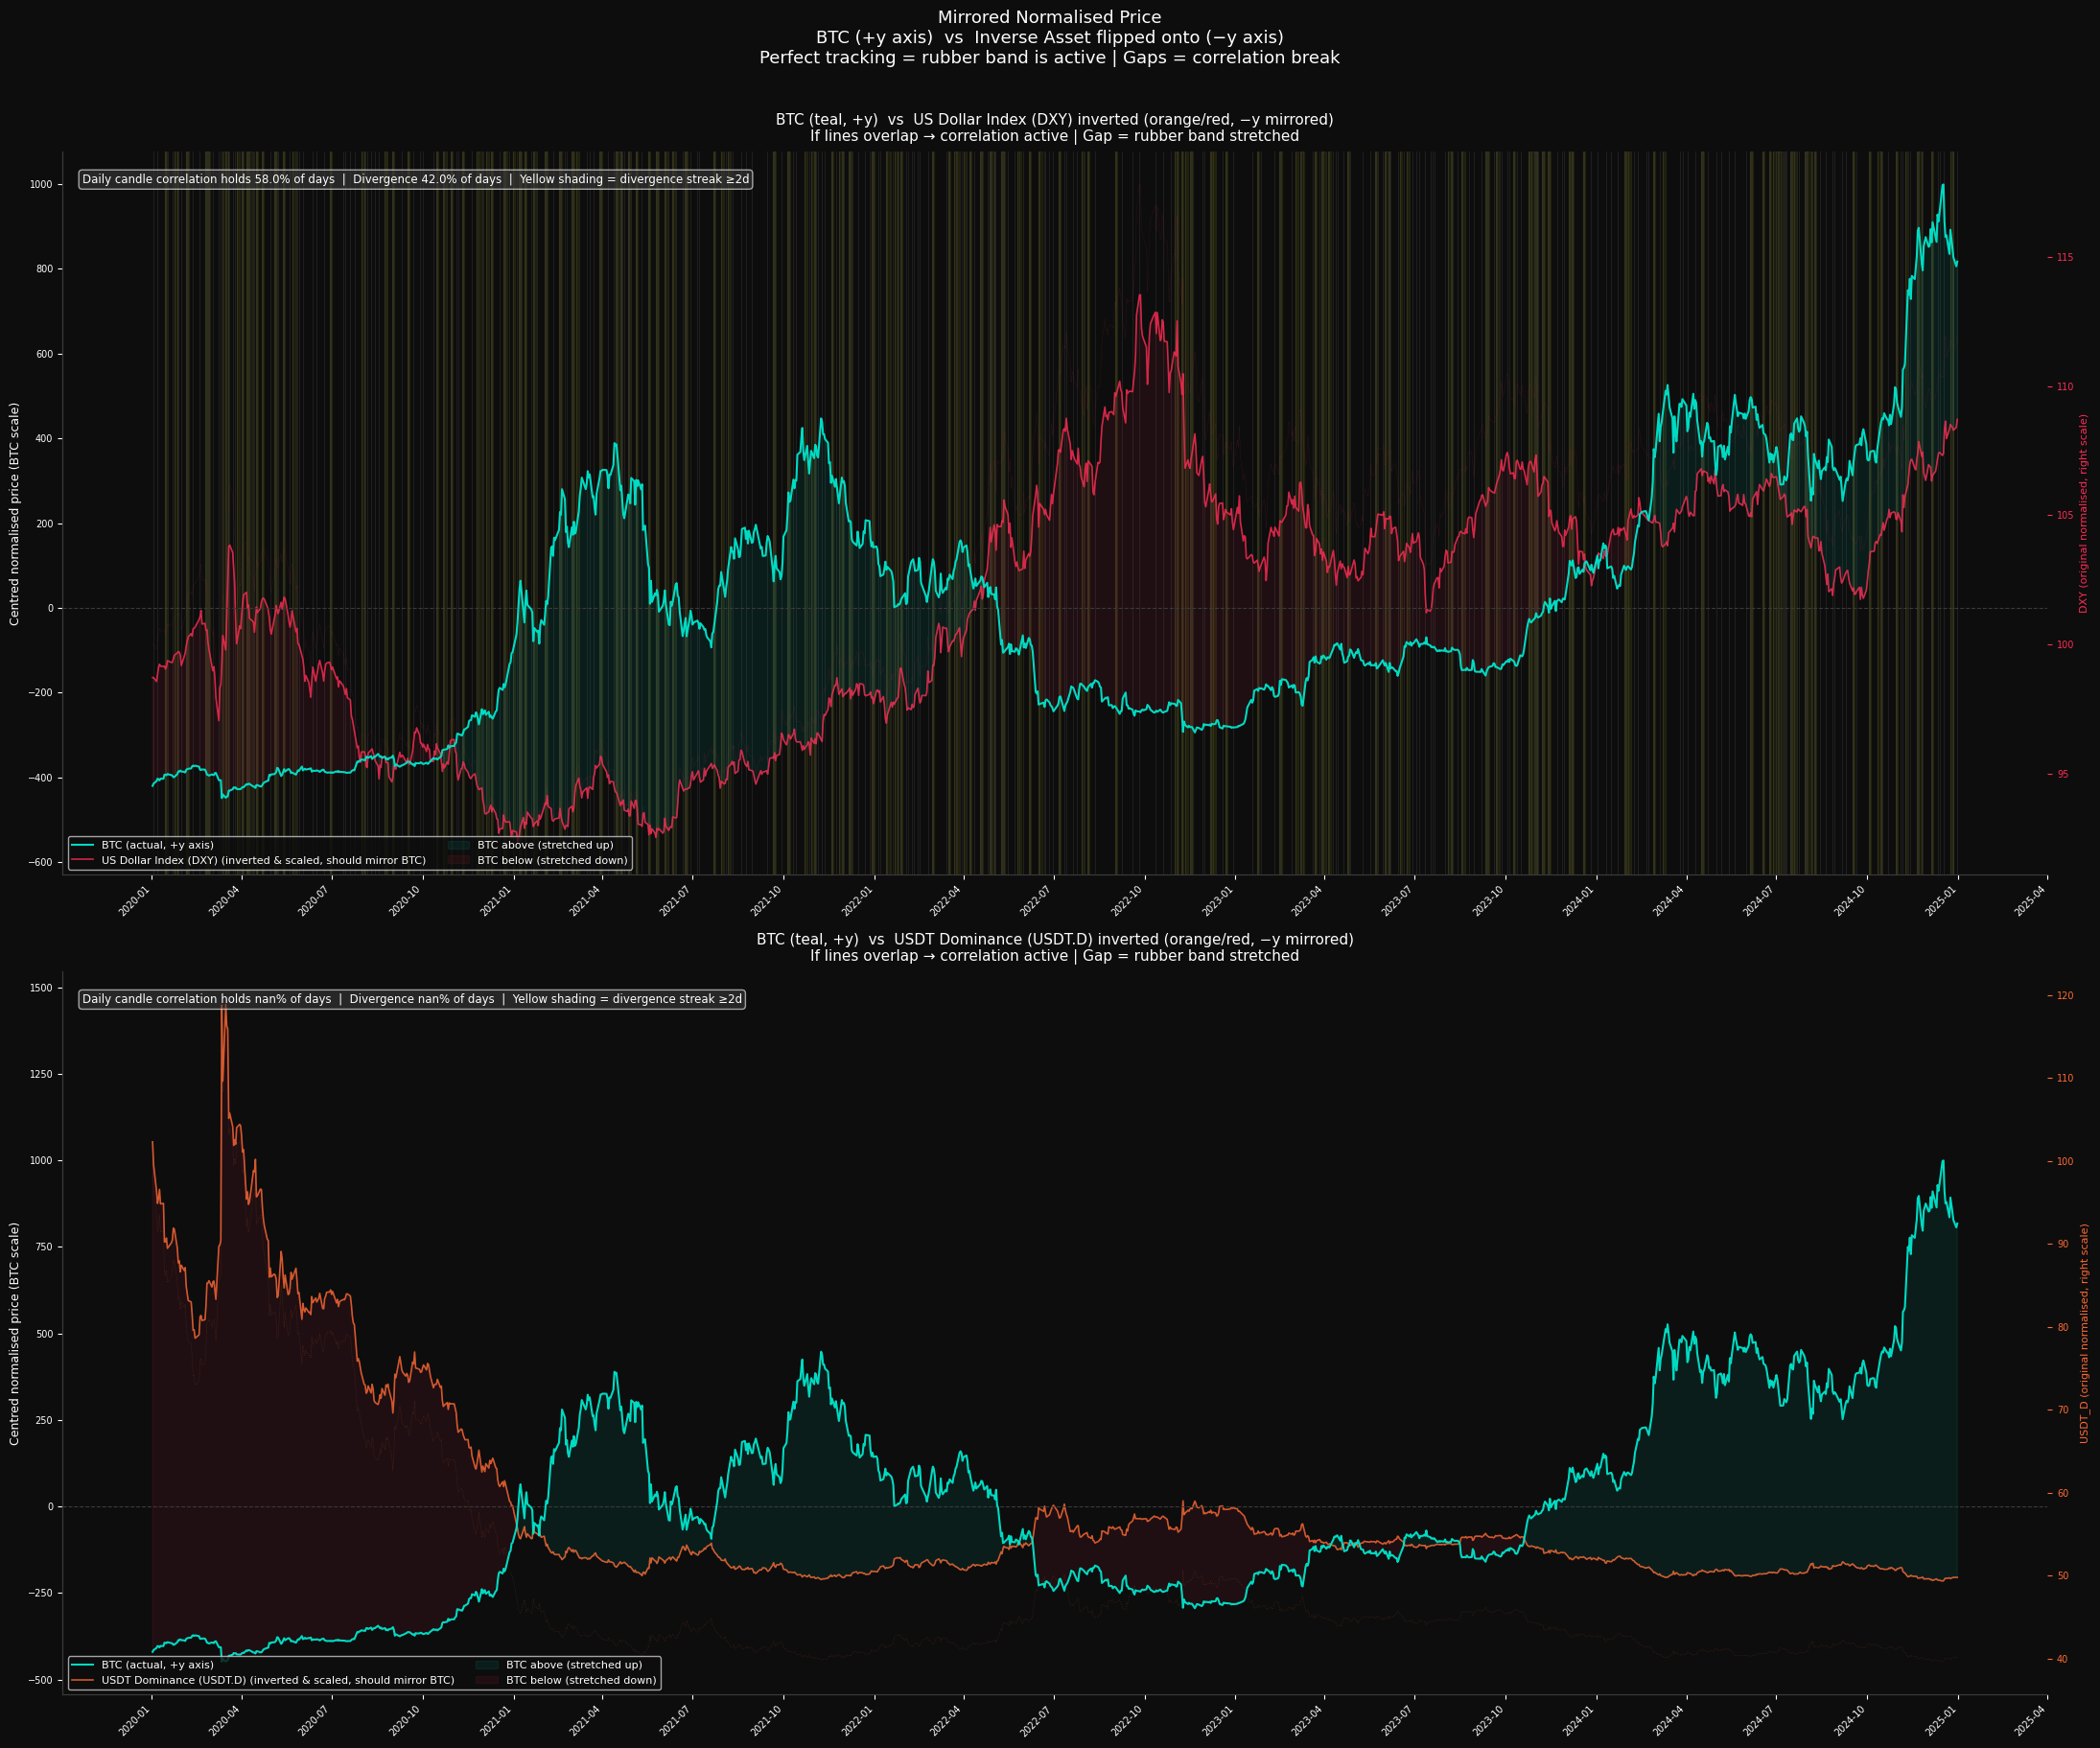

✅ Mirrored normalised plot complete.


In [11]:
# ── Cell 11: Mirrored Normalised Price Plot ───────────────────────────────

BG   = CFG['BG']
TEAL = CFG['TEAL']
RED  = CFG['RED']
ORG  = CFG['ORANGE']
WHT  = CFG['WHITE']
GREY = CFG['GREY']

# ── Mirror transform ───────────────────────────────────────────────────────
# Normalise each series to 0-mean, then flip inverse assets
# This centres both series so their natural level doesn't matter —
# only the SHAPE (direction) of movement is compared

btc_norm_cent = norm_df['BTC'] - norm_df['BTC'].mean()   # centred

n_plots = len(ACTIVE_ASSETS)
fig, axes = plt.subplots(n_plots, 1, figsize=(22, 9 * n_plots), facecolor=BG)
if n_plots == 1:
    axes = [axes]

fig.suptitle(
    'Mirrored Normalised Price\n'
    'BTC (+y axis)  vs  Inverse Asset flipped onto (−y axis)\n'
    'Perfect tracking = rubber band is active | Gaps = correlation break',
    color='white', fontsize=13, y=1.01
)

for ax_idx, asset in enumerate(ACTIVE_ASSETS):
    ax  = axes[ax_idx]
    ax.set_facecolor(BG)
    color = ASSET_META[asset]['color']

    # ── Normalise asset ───────────────────────────────────────────────────
    asset_norm_cent = norm_df[asset] - norm_df[asset].mean()

    # ── Scale asset to BTC's range for visual comparison ─────────────────
    btc_std   = btc_norm_cent.std()
    asset_std = asset_norm_cent.std()
    scale     = btc_std / (asset_std + 1e-10)

    # For INVERSE assets: flip sign so they should align with BTC
    direction = ASSET_META[asset]['direction']   # -1 for DXY and USDT.D
    asset_mirrored = -direction * asset_norm_cent * scale  # flip + scale

    # ── Plot BTC (positive y) ─────────────────────────────────────────────
    ax.plot(norm_df.index, btc_norm_cent.values,
            color=TEAL, lw=1.5, alpha=0.95, label='BTC (actual, +y axis)', zorder=3)

    # ── Plot flipped inverse asset ────────────────────────────────────────
    ax.plot(norm_df.index, asset_mirrored.reindex(norm_df.index).values,
            color=color, lw=1.2, alpha=0.80,
            label=f'{ASSET_META[asset]["label"]} (inverted & scaled, should mirror BTC)',
            zorder=2)

    # ── Shade divergence periods (where candle correlation broke) ─────────
    if asset in CANDLE_RESULTS:
        div_dates = CANDLE_RESULTS[asset]['df'][CANDLE_RESULTS[asset]['df']['divergence']].index
        for dt in div_dates:
            ax.axvline(dt, color='white', alpha=0.08, lw=0.8, zorder=1)

    # ── Shade divergence streaks (≥2 consecutive days) ────────────────────
    if asset in CANDLE_RESULTS and CANDLE_RESULTS[asset]['streaks']:
        for sk in CANDLE_RESULTS[asset]['streaks']:
            start_dt = pd.Timestamp(sk['start'])
            end_dt   = start_dt + pd.Timedelta(days=sk['length'])
            ax.axvspan(start_dt, end_dt, color='yellow', alpha=0.06, zorder=0)

    ax.axhline(0, color=GREY, lw=0.8, ls='--')

    # ── Spread gap fill (shows where they diverge) ────────────────────────
    btc_vals   = btc_norm_cent.reindex(norm_df.index)
    asset_vals = asset_mirrored.reindex(norm_df.index)
    ax.fill_between(norm_df.index, btc_vals, asset_vals,
                    where=(btc_vals > asset_vals),
                    color=TEAL, alpha=0.08, label='BTC above (stretched up)')
    ax.fill_between(norm_df.index, btc_vals, asset_vals,
                    where=(btc_vals < asset_vals),
                    color=RED, alpha=0.08, label='BTC below (stretched down)')

    # ── Right axis: show asset original scale ─────────────────────────────
    ax2 = ax.twinx()
    ax2.set_facecolor(BG)
    ax2.plot(norm_df.index, norm_df[asset].values,
             color=color, lw=0.5, alpha=0.25, ls=':', label=f'{asset} (original scale)')
    ax2.set_ylabel(f'{asset} (original normalised, right scale)',
                   color=color, fontsize=8)
    ax2.tick_params(colors=color, labelsize=7)
    ax2.spines[['top','right']].set_visible(False)
    ax2.spines[['left','bottom']].set_color(GREY)

    # Annotate correlation rate
    if asset in CANDLE_RESULTS:
        cr = CANDLE_RESULTS[asset]['corr_rate'] * 100
        ax.text(0.01, 0.97,
                f'Daily candle correlation holds {cr:.1f}% of days  |  '
                f'Divergence {100-cr:.1f}% of days  |  '
                f'Yellow shading = divergence streak ≥{CFG["DIV_STREAK_MIN"]}d',
                transform=ax.transAxes, color='white', fontsize=8.5, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=GREY, alpha=0.6))

    ax.set_title(
        f'BTC (teal, +y)  vs  {ASSET_META[asset]["label"]} inverted (orange/red, −y mirrored)\n'
        f'If lines overlap → correlation active | Gap = rubber band stretched',
        color='white', fontsize=11, pad=8
    )
    ax.set_ylabel('Centred normalised price (BTC scale)', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=8, labelcolor='white', facecolor=BG, loc='lower left', ncol=2)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color(GREY)

plt.savefig(f'{CFG["FIG_PREFIX"]}mirrored_norm.png', dpi=150,
            bbox_inches='tight', facecolor=BG) if CFG['SAVE_FIGS'] else None
plt.tight_layout()
plt.show()
print('✅ Mirrored normalised plot complete.')

## Cell 12 — Overview Dashboard
Price overlay + rolling correlation + spread z-score for DXY and USDT.D.

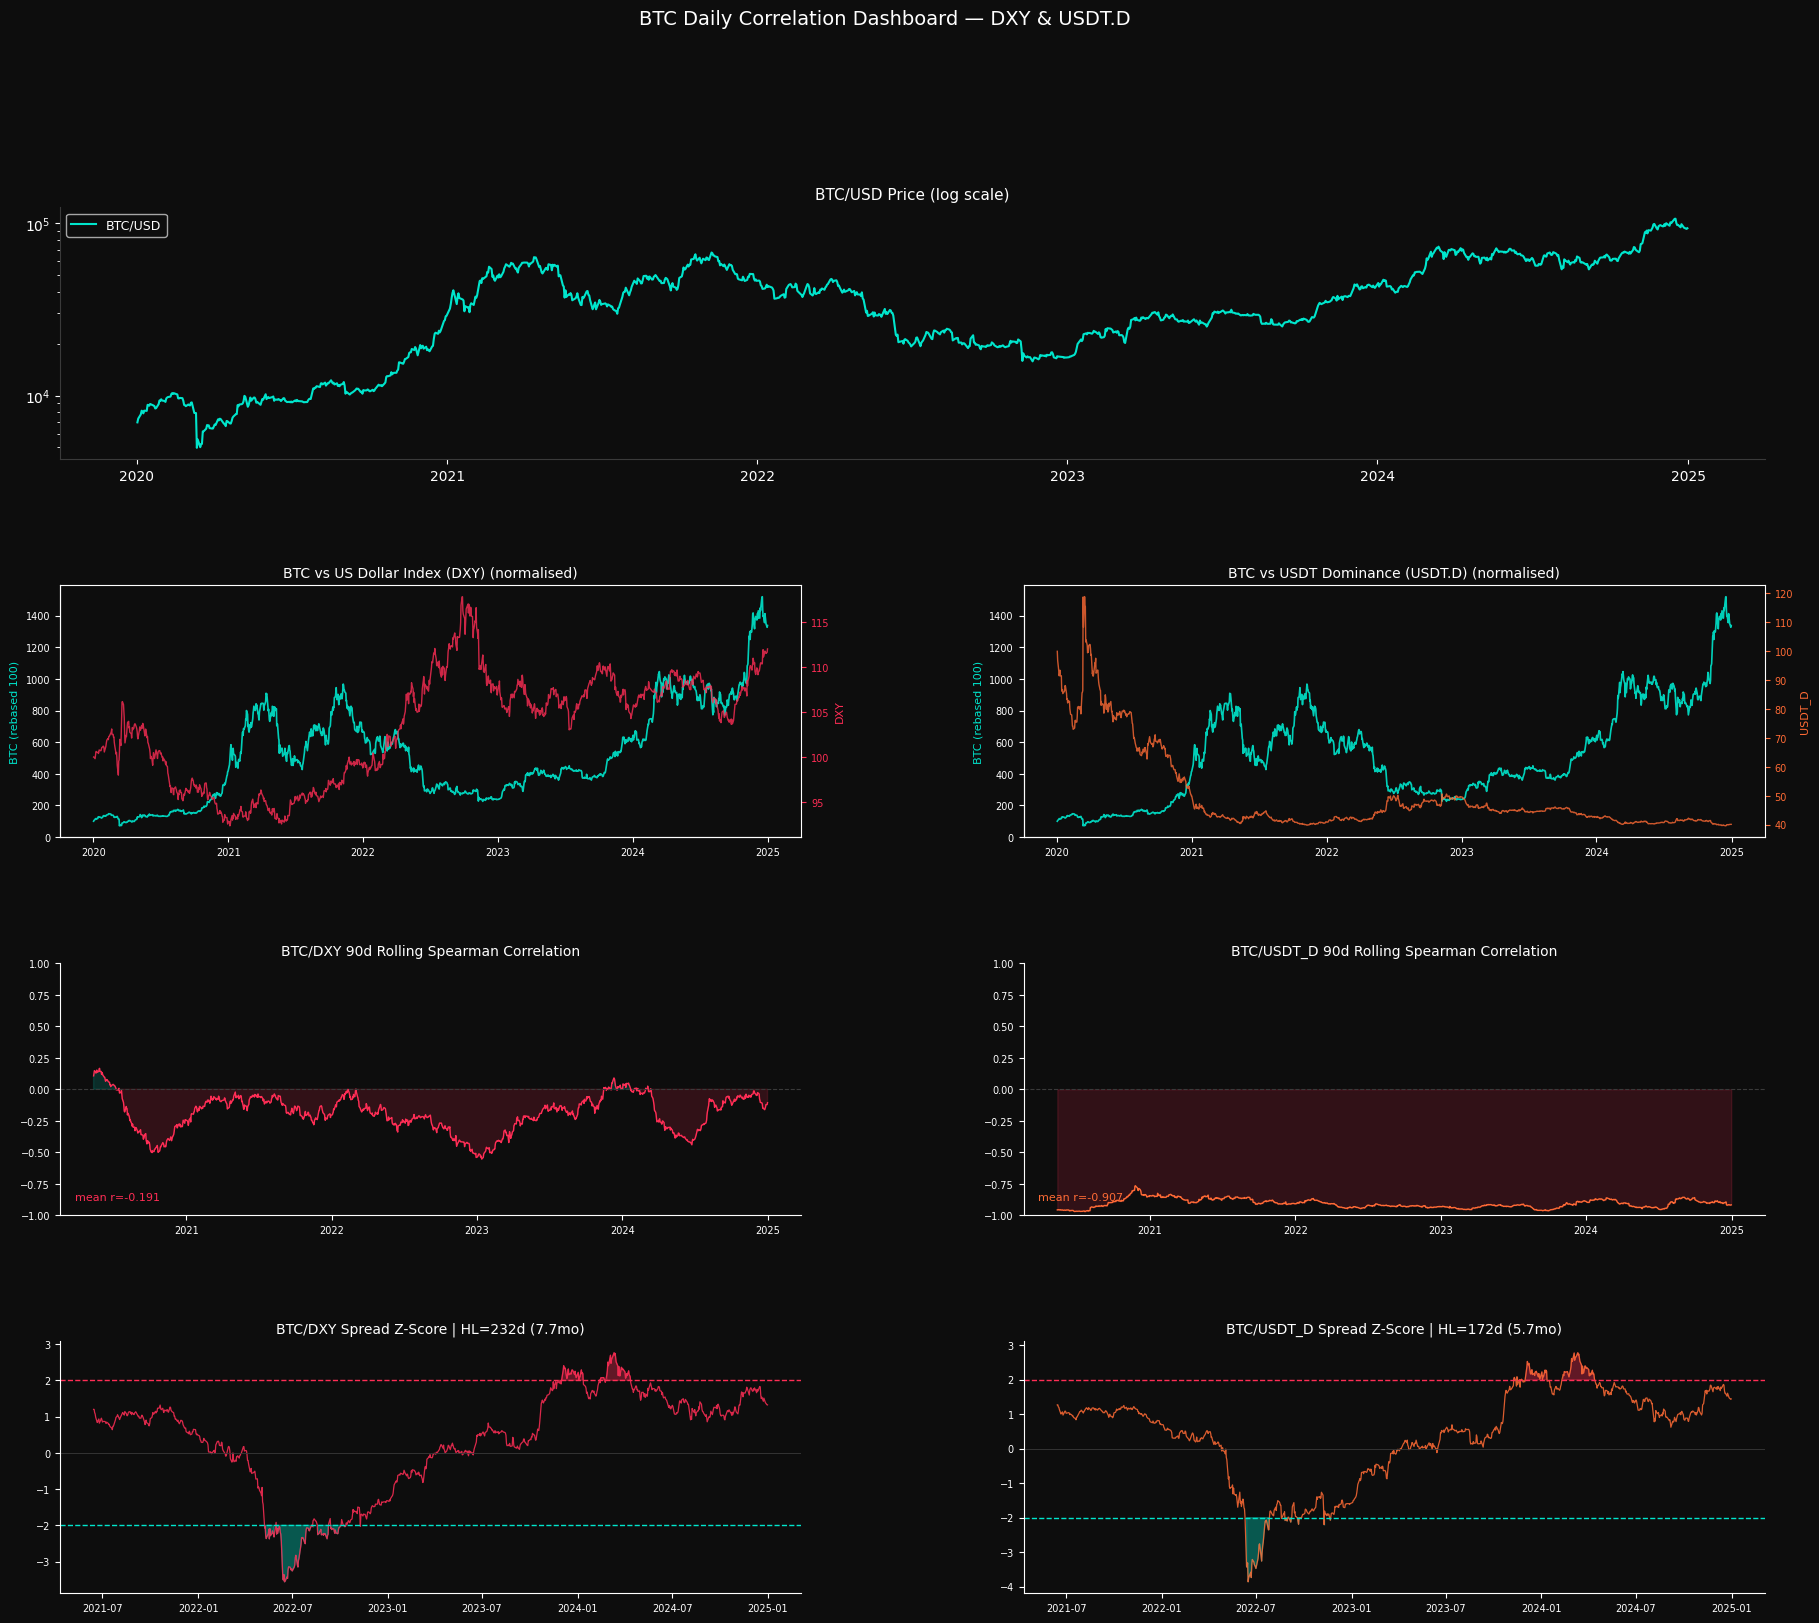

✅ Dashboard plotted.


In [12]:
# ── Cell 12: Overview Dashboard ───────────────────────────────────────────

fig = plt.figure(figsize=(22, 18), facecolor=BG)
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.3)
fig.suptitle('BTC Daily Correlation Dashboard — DXY & USDT.D',
             color='white', fontsize=14, y=0.99)

ax_colors = {'BTC': TEAL, 'DXY': RED, 'USDT_D': ORG}

# ── Plot 1: BTC price (log scale) ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(BG)
ax1.plot(price_df.index, price_df['BTC'], color=TEAL, lw=1.5, label='BTC/USD')
ax1.set_yscale('log')
ax1.set_title('BTC/USD Price (log scale)', color='white', fontsize=11)
ax1.tick_params(colors='white')
ax1.legend(fontsize=9, labelcolor='white', facecolor=BG)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color(GREY)

# ── Plots 2–3: Normalised price overlays ──────────────────────────────────
for i, asset in enumerate(ACTIVE_ASSETS):
    ax = fig.add_subplot(gs[1, i])
    ax.set_facecolor(BG)
    ax.plot(norm_df.index, norm_df['BTC'], color=TEAL, lw=1.2, alpha=0.9, label='BTC')
    ax2r = ax.twinx()
    ax2r.set_facecolor(BG)
    ax2r.plot(norm_df.index, norm_df[asset],
              color=ax_colors.get(asset, ORG), lw=1.0, alpha=0.8,
              label=ASSET_META[asset]['label'])
    ax.set_title(f'BTC vs {ASSET_META[asset]["label"]} (normalised)', color='white', fontsize=10)
    ax.tick_params(colors='white', labelsize=7)
    ax2r.tick_params(colors=ax_colors.get(asset, ORG), labelsize=7)
    ax.set_ylabel('BTC (rebased 100)', color=TEAL, fontsize=8)
    ax2r.set_ylabel(asset, color=ax_colors.get(asset, ORG), fontsize=8)
    ax.spines[['top','right']].set_visible(False)

# ── Plots 4–5: Rolling correlation ────────────────────────────────────────
for i, asset in enumerate(ACTIVE_ASSETS):
    if asset not in RESULTS:
        continue
    ax = fig.add_subplot(gs[2, i])
    ax.set_facecolor(BG)
    rc = RESULTS[asset]['roll_corr']
    color = ax_colors.get(asset, ORG)
    ax.plot(rc.index, rc.values, color=color, lw=1.0)
    ax.fill_between(rc.index, rc.values, 0, where=(rc.values>0), color=TEAL, alpha=0.15)
    ax.fill_between(rc.index, rc.values, 0, where=(rc.values<0), color=RED,  alpha=0.15)
    ax.axhline(0, color=GREY, lw=0.8, ls='--')
    ax.set_ylim(-1, 1)
    ax.set_title(f'BTC/{asset} {CFG["CORR_WINDOW"]}d Rolling Spearman Correlation',
                 color='white', fontsize=10)
    ax.text(0.02, 0.06, f'mean r={rc.mean():.3f}', transform=ax.transAxes,
            color=color, fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[['top','right']].set_visible(False)

# ── Plots 6–7: Spread z-score ──────────────────────────────────────────────
for i, asset in enumerate(ACTIVE_ASSETS):
    if asset not in RESULTS:
        continue
    ax = fig.add_subplot(gs[3, i])
    ax.set_facecolor(BG)
    z = RESULTS[asset]['zscore'].dropna()
    color = ax_colors.get(asset, ORG)
    ax.plot(z.index, z.values, color=color, lw=0.9, alpha=0.85)
    ax.fill_between(z.index, z.values, CFG['ZSCORE_THRESH'],
                    where=(z.values > CFG['ZSCORE_THRESH']), color=RED, alpha=0.35)
    ax.fill_between(z.index, z.values, -CFG['ZSCORE_THRESH'],
                    where=(z.values < -CFG['ZSCORE_THRESH']), color=TEAL, alpha=0.35)
    ax.axhline(CFG['ZSCORE_THRESH'],  color=RED,  lw=1, ls='--')
    ax.axhline(-CFG['ZSCORE_THRESH'], color=TEAL, lw=1, ls='--')
    ax.axhline(0, color=GREY, lw=0.6)
    hl = RESULTS[asset]['half_life']
    ax.set_title(f'BTC/{asset} Spread Z-Score | HL={hl:.0f}d ({hl/30:.1f}mo)',
                 color='white', fontsize=10)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[['top','right']].set_visible(False)

plt.savefig(f'{CFG["FIG_PREFIX"]}dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=BG) if CFG['SAVE_FIGS'] else None
plt.tight_layout()
plt.show()
print('✅ Dashboard plotted.')

## Cell 13 — Divergence Event Visualization
Timeline of candle-direction divergence events. Marks every day where the inverse correlation broke on the BTC price chart.

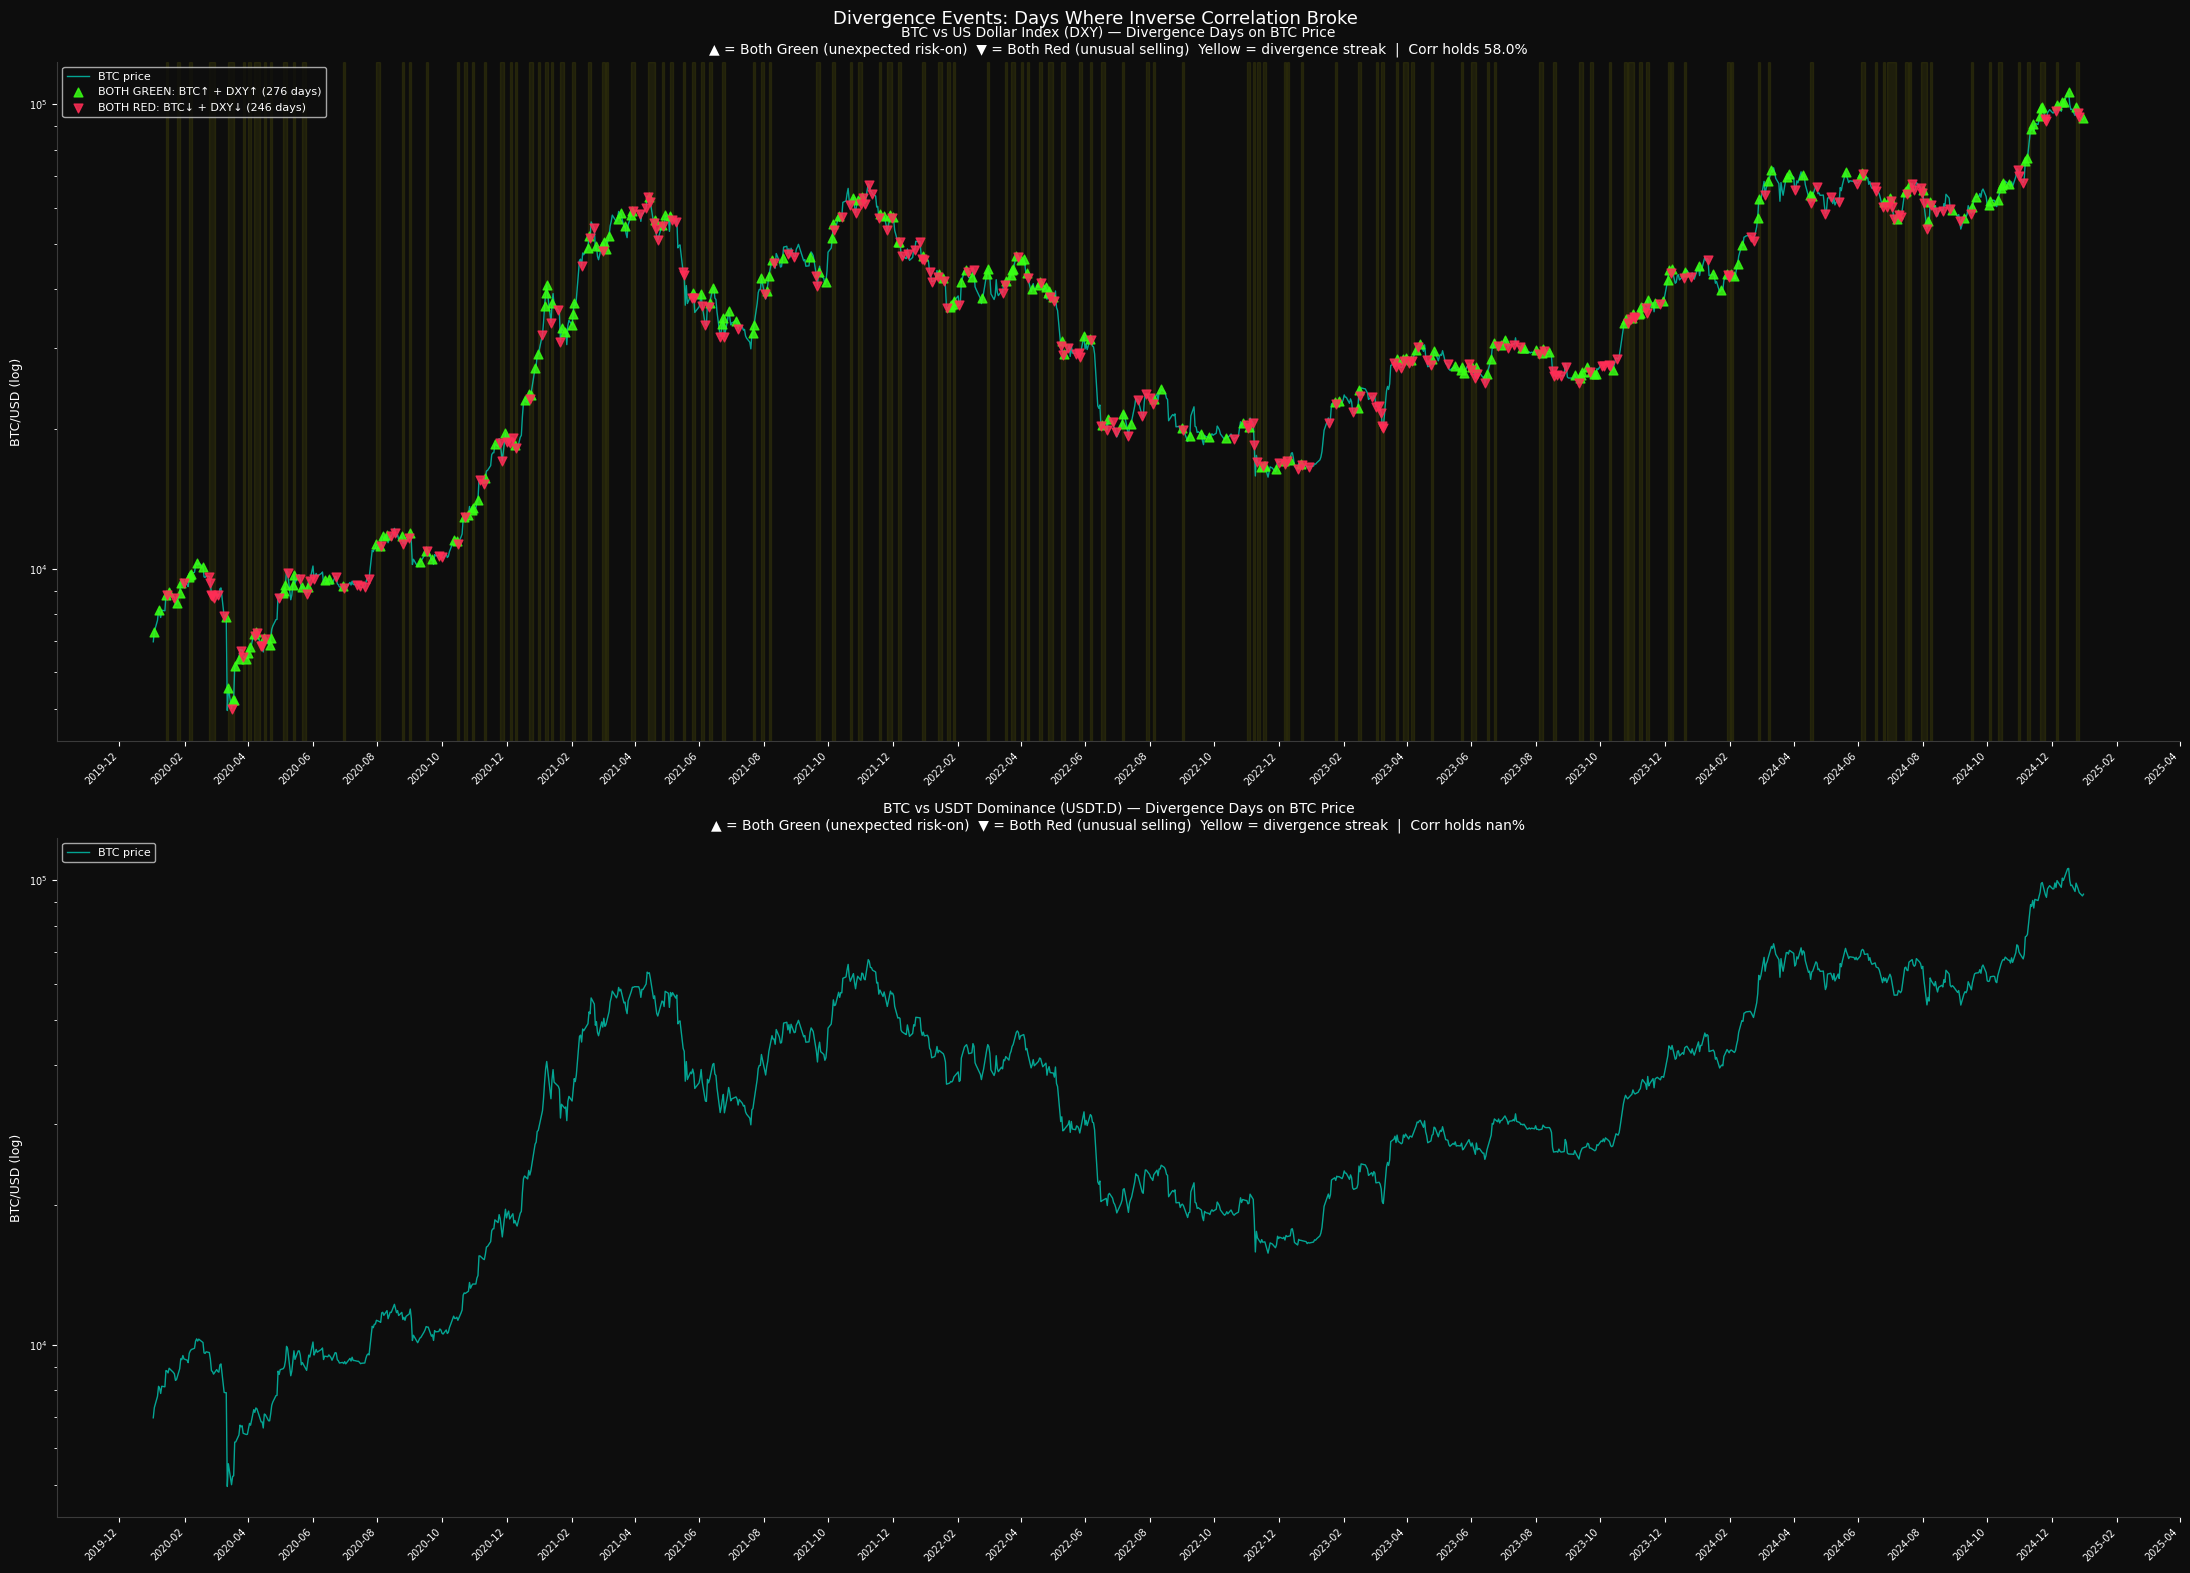

✅ Divergence event chart plotted.


In [13]:
# ── Cell 13: Divergence Events on BTC Price Chart ─────────────────────────

n = len(ACTIVE_ASSETS)
fig, axes = plt.subplots(n, 1, figsize=(22, 8 * n), facecolor=BG)
if n == 1:
    axes = [axes]
fig.suptitle('Divergence Events: Days Where Inverse Correlation Broke',
             color='white', fontsize=13)

for ax_idx, asset in enumerate(ACTIVE_ASSETS):
    ax = axes[ax_idx]
    ax.set_facecolor(BG)

    # BTC price background
    ax.plot(price_df.index, price_df['BTC'], color=TEAL, lw=1.0, alpha=0.7, label='BTC price')
    ax.set_yscale('log')

    if asset not in CANDLE_RESULTS:
        continue

    df_c = CANDLE_RESULTS[asset]['df']

    # Mark BOTH GREEN divergence (BTC up + inverse asset up — unusual)
    both_green = df_c[df_c['div_both_green']]
    if len(both_green) > 0:
        btc_prices_bg = price_df['BTC'].reindex(both_green.index)
        ax.scatter(both_green.index, btc_prices_bg.values,
                   color=CFG['GREEN'], s=40, zorder=5, marker='^',
                   label=f'BOTH GREEN: BTC↑ + {asset}↑ ({len(both_green)} days)',
                   alpha=0.85)

    # Mark BOTH RED divergence (BTC down + inverse asset down)
    both_red = df_c[df_c['div_both_red']]
    if len(both_red) > 0:
        btc_prices_br = price_df['BTC'].reindex(both_red.index)
        ax.scatter(both_red.index, btc_prices_br.values,
                   color=RED, s=40, zorder=5, marker='v',
                   label=f'BOTH RED: BTC↓ + {asset}↓ ({len(both_red)} days)',
                   alpha=0.85)

    # Shade divergence streaks
    for sk in CANDLE_RESULTS[asset]['streaks']:
        s_dt = pd.Timestamp(sk['start'])
        e_dt = s_dt + pd.Timedelta(days=sk['length'])
        ax.axvspan(s_dt, e_dt, color='yellow', alpha=0.07)

    corr_rate = CANDLE_RESULTS[asset]['corr_rate'] * 100
    ax.set_title(
        f'BTC vs {ASSET_META[asset]["label"]} — Divergence Days on BTC Price\n'
        f'▲ = Both Green (unexpected risk-on)  ▼ = Both Red (unusual selling)  '
        f'Yellow = divergence streak  |  Corr holds {corr_rate:.1f}%',
        color='white', fontsize=10
    )
    ax.set_ylabel('BTC/USD (log)', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=8, labelcolor='white', facecolor=BG, loc='upper left')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color(GREY)

plt.savefig(f'{CFG["FIG_PREFIX"]}divergence_events.png', dpi=150,
            bbox_inches='tight', facecolor=BG) if CFG['SAVE_FIGS'] else None
plt.tight_layout()
plt.show()
print('✅ Divergence event chart plotted.')

## Cell 14 — HMM Regimes + Kalman Beta Charts

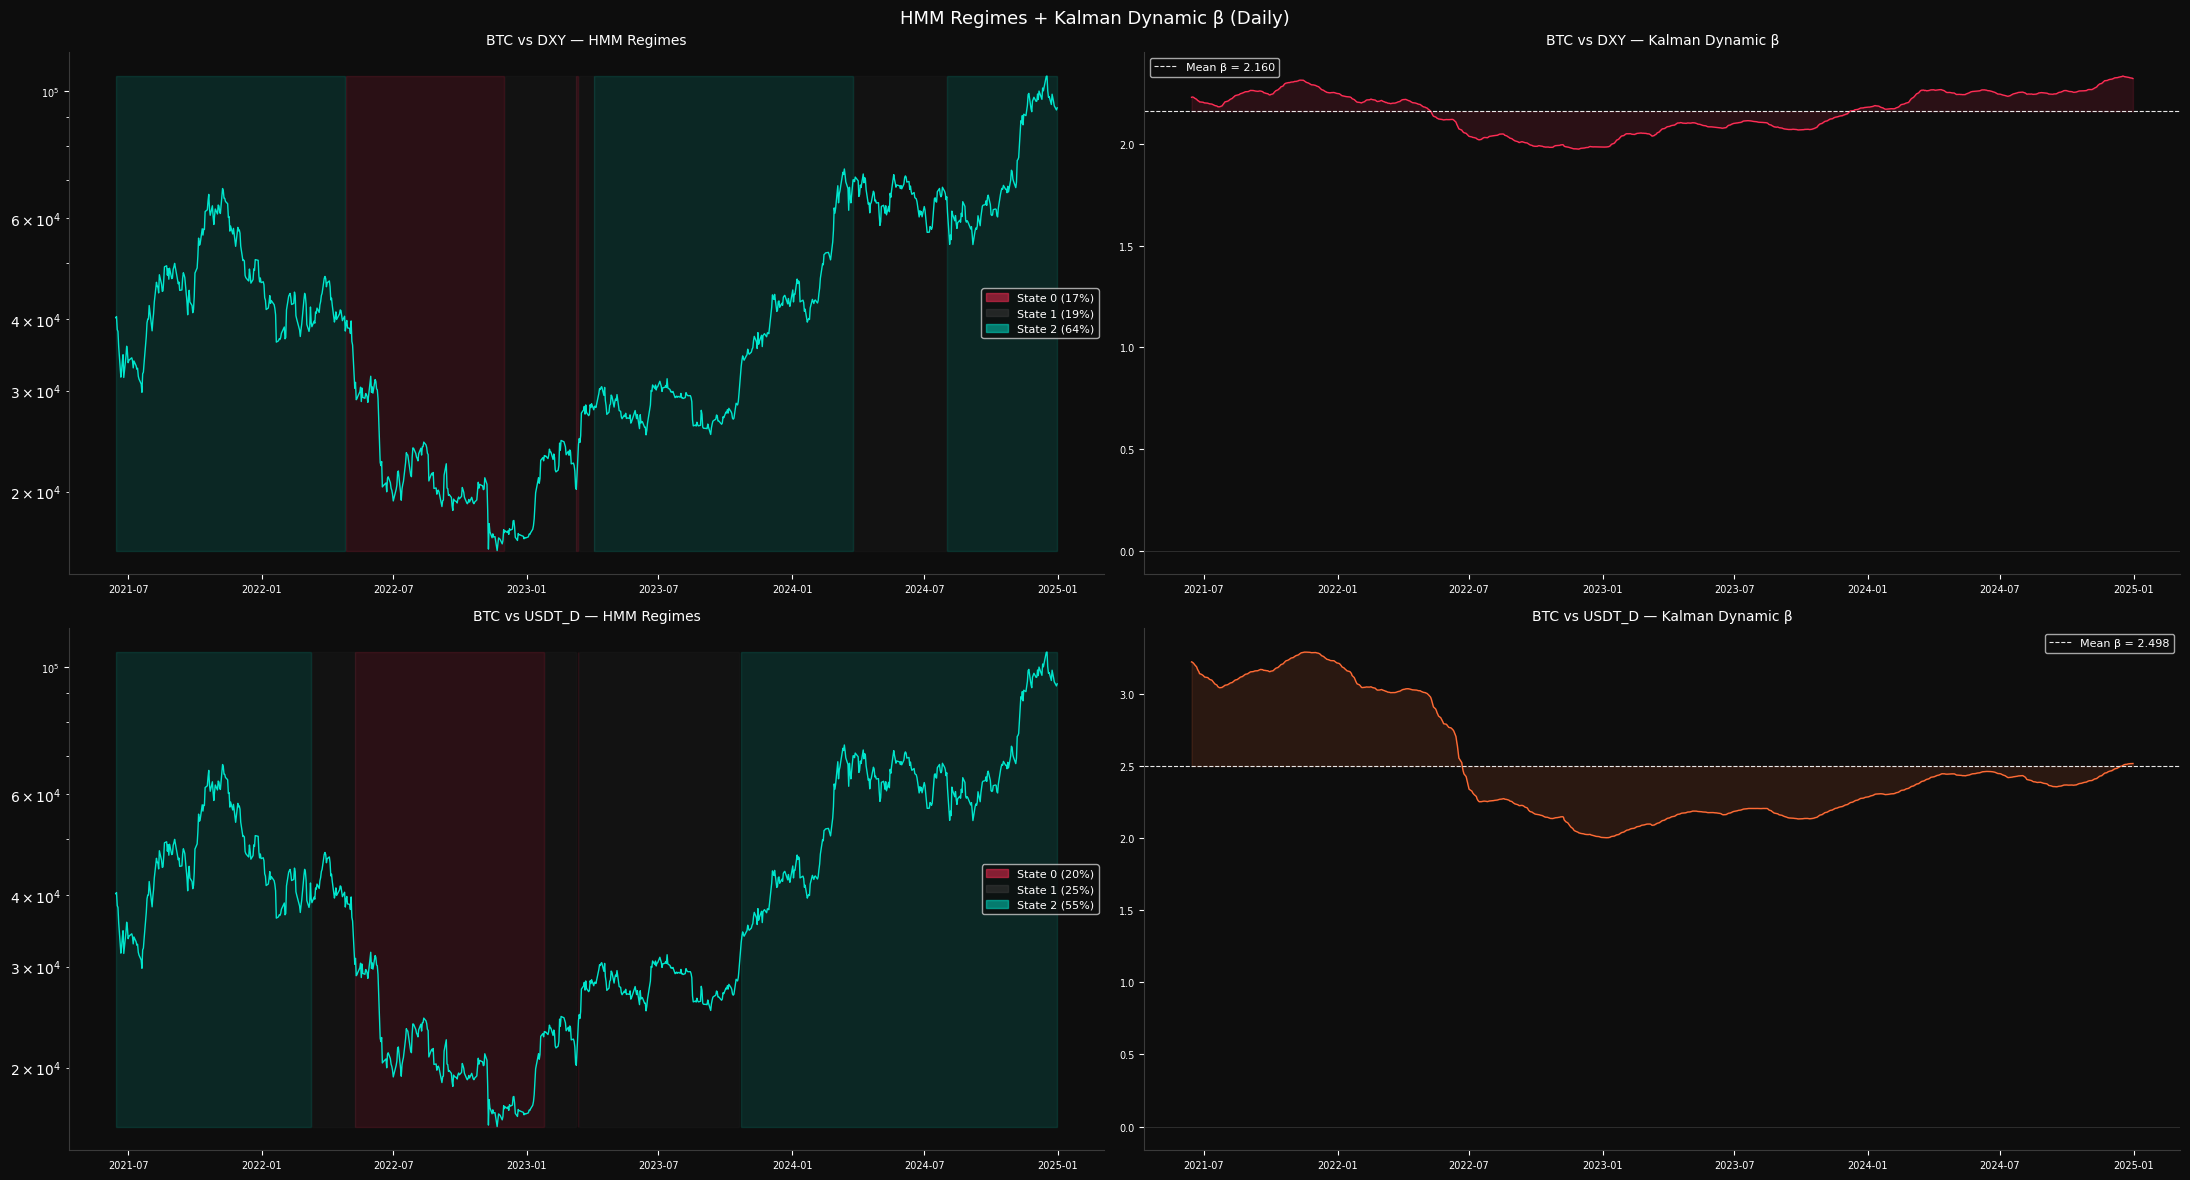

✅ HMM + Kalman plotted.


In [14]:
# ── Cell 14: HMM Regime Overlay + Kalman β Drift ─────────────────────────

regime_colors = [RED, GREY, TEAL]
assets_hmm    = [a for a in ACTIVE_ASSETS if a in HMM_RESULTS]
n = len(assets_hmm)
if n == 0:
    print('No HMM results to plot.')
else:
    fig, axes = plt.subplots(n, 2, figsize=(22, 6*n), facecolor=BG)
    if n == 1: axes = axes[np.newaxis, :]
    fig.suptitle('HMM Regimes + Kalman Dynamic β (Daily)', color='white', fontsize=13)

    for i, asset in enumerate(assets_hmm):
        hmm    = HMM_RESULTS[asset]
        states = hmm['states']
        btc_p  = price_df['BTC'].reindex(states.index)
        beta   = RESULTS[asset]['beta'].reindex(states.index)
        color  = ax_colors.get(asset, ORG)

        # Left: BTC with regime shading
        ax_l = axes[i, 0]
        ax_l.set_facecolor(BG)
        for s in range(CFG['HMM_STATES']):
            mask = (states == s).values
            ax_l.fill_between(states.index, btc_p.min(), btc_p.max(),
                               where=mask, color=regime_colors[s], alpha=0.12)
        ax_l.plot(btc_p.index, btc_p.values, color=TEAL, lw=1.0)
        ax_l.set_yscale('log')
        ax_l.set_title(f'BTC vs {asset} — HMM Regimes', color='white', fontsize=10)
        patches = [mpatches.Patch(color=regime_colors[j], alpha=0.5,
                                   label=f'State {j} ({(states==j).mean()*100:.0f}%)')
                   for j in range(CFG['HMM_STATES'])]
        ax_l.legend(handles=patches, fontsize=8, labelcolor='white', facecolor=BG)
        ax_l.tick_params(colors='white', labelsize=7)
        ax_l.spines[['top','right']].set_visible(False)
        ax_l.spines[['left','bottom']].set_color(GREY)

        # Right: Kalman β
        ax_r = axes[i, 1]
        ax_r.set_facecolor(BG)
        ax_r.plot(beta.index, beta.values, color=color, lw=1.0)
        ax_r.axhline(beta.mean(), color=WHT, lw=0.8, ls='--',
                     label=f'Mean β = {beta.mean():.3f}')
        ax_r.axhline(0, color=GREY, lw=0.5)
        ax_r.fill_between(beta.index, beta.values, beta.mean(), color=color, alpha=0.12)
        ax_r.set_title(f'BTC vs {asset} — Kalman Dynamic β', color='white', fontsize=10)
        ax_r.legend(fontsize=8, labelcolor='white', facecolor=BG)
        ax_r.tick_params(colors='white', labelsize=7)
        ax_r.spines[['top','right']].set_visible(False)
        ax_r.spines[['left','bottom']].set_color(GREY)

    plt.savefig(f'{CFG["FIG_PREFIX"]}hmm_kalman.png', dpi=150,
                bbox_inches='tight', facecolor=BG) if CFG['SAVE_FIGS'] else None
    plt.tight_layout()
    plt.show()
    print('✅ HMM + Kalman plotted.')

## Cell 15 — Compiled Summary
All findings in one structured output.

In [15]:
# ── Cell 15: Compiled Summary ─────────────────────────────────────────────

sep = '='*75
print(sep)
print('  BTC DAILY CORRELATION — COMPILED SUMMARY')
print(f'  Assets: BTC vs DXY + USDT.D  |  {CFG["START_DATE"]} → {CFG["END_DATE"]}  |  Daily bars')
print(sep)

print('\n1. CORRELATION (full period, daily returns):')
print(f'{"Asset":<10} {"Pearson r":<12} {"Spearman r":<14} {"Expected":<10} {"Actual"}')
print('-'*60)
for asset in ACTIVE_ASSETS:
    if asset not in RESULTS: continue
    exp = ASSET_META[asset]['direction']
    act = int(np.sign(RESULTS[asset]['spearman_r']))
    ok  = '✅' if act == exp else '⚠️'
    print(f"{asset:<10} {RESULTS[asset]['pearson_r']:>+.4f}       "
          f"{RESULTS[asset]['spearman_r']:>+.4f}         {exp:<10} {act}  {ok}")

print('\n2. COINTEGRATION:')
print(f'{"Asset":<10} {"Cointegrated":<15} {"p-value":<12} {"Spread ADF p":<15} {"Half-life (days)"}')
print('-'*70)
for asset in ACTIVE_ASSETS:
    if asset not in RESULTS: continue
    r  = RESULTS[asset]
    hl = r['half_life']
    print(f"{asset:<10} {'YES ✅' if r['cointegrated'] else 'NO  ❌':<15}"
          f"{r['coint_p']:.4f}       {r['adf_p']:.4f}          "
          f"{hl:.0f}d (~{hl/30:.1f}mo)")

print('\n3. RUBBER BAND METRICS:')
print(f'{"Asset":<10} {"Max stretch":<14} {"% time >2σ":<13} {"Extremes(n)"}')
print('-'*55)
for asset in ACTIVE_ASSETS:
    if asset not in STRETCH or asset not in RESULTS: continue
    st = STRETCH[asset]
    print(f"{asset:<10} {st['max_z']:.2f}σ{'':>9} "
          f"{st['pct_2sd']:.1f}%{'':>8} "
          f"{len(RESULTS[asset]['extreme_events'])}")

print('\n4. CANDLE DIRECTION CORRELATION:')
print(f'{"Asset":<10} {"Total days":<13} {"Corr holds":<13} {"Hold %":<10} {"Divergence":<13} {"Both Green":<13} {"Both Red"}')
print('-'*85)
for asset in ACTIVE_ASSETS:
    if asset not in CANDLE_RESULTS: continue
    cr = CANDLE_RESULTS[asset]
    df = cr['df']
    print(f"{asset:<10} {cr['n_total']:<13} {cr['n_corr']:<13} "
          f"{cr['corr_rate']*100:.1f}%{'':>5} {cr['n_div']:<13} "
          f"{df['div_both_green'].sum():<13} {df['div_both_red'].sum()}")

print('\n5. BTC FORWARD RETURN AFTER DIVERGENCE (BOTH MOVING SAME DIRECTION):')
for asset in ACTIVE_ASSETS:
    if asset not in CANDLE_RESULTS: continue
    fwd = CANDLE_RESULTS[asset]['fwd_df']
    if len(fwd) == 0: continue
    print(f'\n  {asset}:')
    summary = fwd.groupby(['div_type','fwd_days'])['btc_ret'].agg(
        mean='mean', win_pct=lambda x: (x>0).mean()*100, count='count'
    ).round(3)
    print(summary.to_string())

print(f'\n{sep}')
print('  KEY TAKEAWAYS:')
for asset in ACTIVE_ASSETS:
    if asset not in CANDLE_RESULTS or asset not in RESULTS: continue
    cr_rate = CANDLE_RESULTS[asset]['corr_rate'] * 100
    hl      = RESULTS[asset]['half_life']
    print(f'\n  {asset}:')
    print(f'    • Inverse candle correlation holds {cr_rate:.1f}% of daily trading days')
    print(f'    • Rubber band half-life: ~{hl:.0f} days ({hl/30:.1f} months)')
    print(f'    • Cointegrated: {"YES" if RESULTS[asset]["cointegrated"] else "NO"}')
    print(f'    • Divergence: {100-cr_rate:.1f}% of days — check forward return table for edge')
print(f'{sep}')

  BTC DAILY CORRELATION — COMPILED SUMMARY
  Assets: BTC vs DXY + USDT.D  |  2020-01-01 → 2025-01-01  |  Daily bars

1. CORRELATION (full period, daily returns):
Asset      Pearson r    Spearman r     Expected   Actual
------------------------------------------------------------
DXY        -0.1479       -0.1811         -1         -1  ✅
USDT_D     -0.7767       -0.8810         -1         -1  ✅

2. COINTEGRATION:
Asset      Cointegrated    p-value      Spread ADF p    Half-life (days)
----------------------------------------------------------------------
DXY        NO  ❌          0.7901       0.5260          232d (~7.7mo)
USDT_D     NO  ❌          0.8792       0.3665          172d (~5.7mo)

3. RUBBER BAND METRICS:
Asset      Max stretch    % time >2σ    Extremes(n)
-------------------------------------------------------
DXY        3.56σ          18.2%         163
USDT_D     3.86σ          13.4%         120

4. CANDLE DIRECTION CORRELATION:
Asset      Total days    Corr holds    Hold %   